In [1]:
import sys

print(sys.executable)

/home/yeffrey/Descargas/smart-logistics-delay-prediction/.venv/bin/python


In [ ]:
# Celda 1 - Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [7]:
#Celda 2 - Cargar dataset
df = pd.read_csv("../data/raw/smart_logistics_dataset.csv")

df.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [4]:
#Celda 3 - Exploración inicial
print("Shape:", df.shape)

df.info()

Shape: (1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   str    
 1   Asset_ID                 1000 non-null   str    
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   str    
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   str    
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    str    
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast   

In [5]:
# Celda 4 - Columnas

df.columns.tolist()

['Timestamp',
 'Asset_ID',
 'Latitude',
 'Longitude',
 'Inventory_Level',
 'Shipment_Status',
 'Temperature',
 'Humidity',
 'Traffic_Status',
 'Waiting_Time',
 'User_Transaction_Amount',
 'User_Purchase_Frequency',
 'Logistics_Delay_Reason',
 'Asset_Utilization',
 'Demand_Forecast',
 'Logistics_Delay']

In [6]:
# Celda 5 - Nulos

df.isnull().sum()

Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

In [8]:
df["Logistics_Delay"].value_counts()

Logistics_Delay
1    566
0    434
Name: count, dtype: int64

In [9]:
pd.crosstab(df["Shipment_Status"], df["Logistics_Delay"])

Logistics_Delay,0,1
Shipment_Status,,
Delayed,0,350
Delivered,220,118
In Transit,214,98


In [10]:
df["Logistics_Delay_Reason"].value_counts(dropna=False)

Logistics_Delay_Reason
Weather               267
NaN                   263
Traffic               236
Mechanical Failure    234
Name: count, dtype: int64

In [20]:
# Celda - Preparar variables
columns_to_drop = [
    "Logistics_Delay",
    "Asset_ID",
    "Timestamp",
    "Shipment_Status",
    "Logistics_Delay_Reason"
]

X = df.drop(columns=columns_to_drop)

y = df["Logistics_Delay"]

In [21]:
# Celda - Separar variables categóricas y numéricas
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categoricas:", categorical_features)
print("Numericas:", numeric_features)

Categoricas: ['Traffic_Status']
Numericas: ['Latitude', 'Longitude', 'Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Asset_Utilization', 'Demand_Forecast']


/tmp/ipykernel_269148/1997665226.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [22]:
# Celda - Pipeline

from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        )
    ]
)

In [23]:
#Celda - Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
# Celda - Random Forest
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [25]:
# Celda - Evaluación
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.745

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.91      0.76        87
           1       0.90      0.62      0.73       113

    accuracy                           0.74       200
   macro avg       0.77      0.76      0.74       200
weighted avg       0.79      0.74      0.74       200



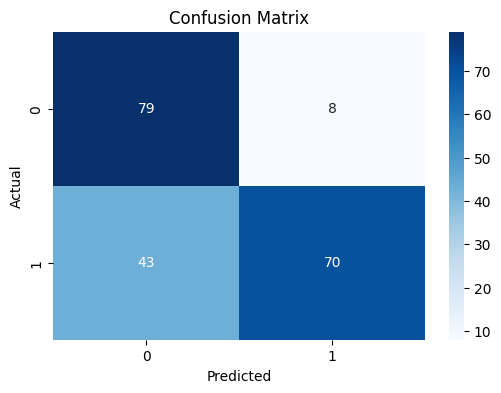

In [26]:
# Celda - Matriz de confusión
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
joblib.dump(model, "../models/logistics_delay_model.pkl")

['../models/logistics_delay_model.pkl']

In [28]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df.head(15)

,feature,importance
2,cat__Traffic_Status_Heavy,0.249116
1,cat__Traffic_Status_Detour,0.074723
0,cat__Traffic_Status_Clear,0.069902
3,num__Latitude,0.069436
5,num__Inventory_Level,0.067155
11,num__Asset_Utilization,0.066507
6,num__Temperature,0.064217
4,num__Longitude,0.063719
9,num__User_Transaction_Amount,0.061294
7,num__Humidity,0.060562


In [29]:
import joblib

joblib.dump(
    model,
    "../models/logistics_delay_model.pkl"
)

['../models/logistics_delay_model.pkl']

In [30]:
import os

os.path.exists("../models/logistics_delay_model.pkl")

True

In [31]:
pd.Series(model.predict(X_test)).value_counts()

0    122
1     78
Name: count, dtype: int64

In [32]:
y_test.value_counts()

Logistics_Delay
1    113
0     87
Name: count, dtype: int64